### Objective
To learn Python basics and perform data exploration, cleaning, transformation, and analysis using the Pandas library on a real-world shopping dataset.

### Dataset Used
`combined_dataset.csv`

## Step 1: Loading CSV Dataset into a Pandas DataFrame

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)


# Reading Dataset
df = pd.read_csv('../data/shopping_dataset.csv')
print(f'✅ Dataset loaded successfully!')


✅ Dataset loaded successfully!


## Step 2: Exploring the Dataset
### View First and Last Records, Shape, Columns, Data Types, and Summary Statistics

In [2]:
print(f'Shape: {df.shape[0]} rows × {df.shape[1]} columns') # Shape

df.head() # Reads first 5 rows
df.tail() # Reads last 5 rows

# Retreiving Shape (Rows, Columns)
rows, cols = df.shape
print(f'Rows   : {rows}')
print(f'Columns: {cols}')
print('Columns:')
for i, col in enumerate(df.columns, 1):
    print(f'  {i}. {col}')

print(df.dtypes) # Priting DataTypes
print(
    f"Memory Usage: "
    f"{df.memory_usage(deep=True).sum()/1024:.2f} KB" # Memory Usage
)
df.info() # Dataset Info
df.describe() # Statistical Summary

Shape: 1000 rows × 24 columns
Rows   : 1000
Columns: 24
Columns:
  1. product_id
  2. title
  3. product_description
  4. rating
  5. ratings_count
  6. initial_price
  7. discount
  8. final_price
  9. currency
  10. images
  11. delivery_options
  12. product_details
  13. breadcrumbs
  14. product_specifications
  15. amount_of_stars
  16. what_customers_said
  17. seller_name
  18. sizes
  19. videos
  20. seller_information
  21. variations
  22. best_offer
  23. more_offers
  24. category
product_id                  int64
title                      object
product_description        object
rating                    float64
ratings_count               int64
initial_price               int64
discount                  float64
final_price                object
currency                   object
images                     object
delivery_options           object
product_details            object
breadcrumbs                object
product_specifications     object
amount_of_stars         

,product_id,rating,ratings_count,initial_price,discount
count,1000.00,1000.00,1000.00,1000.00,879.00
mean,17134372.58,3.62,76.69,2723.24,53.50
std,3813765.76,1.37,241.11,2408.70,18.03
min,586846.00,0.00,0.00,249.00,1.00
25%,15115009.50,3.70,7.00,1399.00,44.00
50%,18208901.00,4.10,17.00,1999.00,56.00
75%,19027372.00,4.30,58.00,3299.00,66.00
max,22747068.00,5.00,4441.00,22199.00,88.00


## Step 3: Handling Missing Values
### Identify, Analyze, and Fill Missing Data

In [3]:
# Check missing values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)
print(f'\nTotal missing cells: {df.isnull().sum().sum()}')

# Missing value which are as percentage
missing_pct = (
    df.isnull().sum() / len(df) * 100
).round(2)
print('\nMissing value % per column:')
print(missing_pct[missing_pct > 0])


# Clean price columns
df['initial_price'] = pd.to_numeric( # Converting to int
    df['initial_price'],
    errors='coerce'
)
df['final_price'] = (
    df['final_price']
    .astype(str)
    .str.replace('"', '', regex=False) 
    .str.replace('₹', '', regex=False) # Removing prefix and unwanted chars
    .str.replace(',', '', regex=False)
    .str.strip()
)
df['final_price'] = pd.to_numeric( # Converting to int
    df['final_price'],
    errors='coerce'
)
df['discount'] = pd.to_numeric( # Converting to int
    df['discount'],
    errors='coerce'
)


# Fill missing values (all columns)
df['rating'] = df['rating'].fillna(df['rating'].median())
df['ratings_count'] = df['ratings_count'].fillna(0)
df['discount'] = df['discount'].fillna(df['discount'].median())
df['seller_name'] = df['seller_name'].fillna('Unknown Seller')
df['category'] = df['category'].fillna('Unknown Category')
df['what_customers_said'] = df['what_customers_said'].fillna(
    'No customer feedback available'
)
df['videos'] = df['videos'].fillna(
    'No video available'
)
df['seller_information'] = df['seller_information'].fillna(
    'Information not available'
)
df['variations'] = df['variations'].fillna(
    'No variations available'
)

# Verify cleaning and printing stats
print('\nAfter filling missing values:')
print(df.isnull().sum())
print(
    f'\nTotal missing cells remaining: '
    f'{df.isnull().sum().sum()}'
)
print('\nUpdated Data Types:')
print(
    df[['initial_price', 'final_price', 'discount']].dtypes
)
print('\nPrice Columns Preview:')
print(
    df[['initial_price', 'final_price', 'discount']]
    .head()
)

Missing values per column:
product_id                  0
title                       0
product_description         0
rating                      0
ratings_count               0
initial_price               0
discount                  121
final_price                 0
currency                    0
images                      0
delivery_options            0
product_details             0
breadcrumbs                 0
product_specifications      0
amount_of_stars             0
what_customers_said       573
seller_name               301
sizes                       0
videos                    781
seller_information        301
variations                562
best_offer                  0
more_offers                 0
category                    0
dtype: int64

Total missing cells: 2639

Missing value % per column:
discount              12.10
what_customers_said   57.30
seller_name           30.10
videos                78.10
seller_information    30.10
variations            56.20
dtype: float64



## Step 4: Performing Basic Data Operations
### Select Columns, Filter Rows, and Sort Data

In [4]:
# Select specific columns
selected_columns = df[
    [
        'product_id',
        'title',
        'category',
        'final_price',
        'rating'
    ]
]
print("Selected Columns:")
print(selected_columns.head())


# Filter products with rating >= 4
high_rated_products = df[
    df['rating'] >= 4
]
print("\nProducts with Rating >= 4:")
print(
    high_rated_products[
        [
            'title',
            'rating',
            'final_price'
        ]
    ].head()
)


# Filter products with final price > 2000
expensive_products = df[
    df['final_price'] > 2000
]
print("\nProducts with Final Price > 2000:")
print(
    expensive_products[
        [
            'title',
            'category',
            'final_price'
        ]
    ].head()
)


# Filter products from the first category in dataset
category_products = df[
    df['category'] == df['category'].iloc[0]
]
print("\nProducts from First Category:")
print(
    category_products[
        [
            'title',
            'category',
            'final_price'
        ]
    ].head()
)

# Sort products by final price (highest to lowest)
sorted_by_price = df.sort_values(
    by='final_price',
    ascending=False
)
print("\nTop 5 Most Expensive Products:")
print(
    sorted_by_price[
        [
            'title',
            'category',
            'final_price',
            'rating'
        ]
    ].head(5)
)


# Sort products by rating (highest to lowest)
top_rated_products = df.sort_values(
    by='rating',
    ascending=False
)
print("\nTop 5 Highest Rated Products:")
print(
    top_rated_products[
        [
            'title',
            'rating',
            'ratings_count',
            'final_price'
        ]
    ].head(5)
)

Selected Columns:
   product_id           title   category  final_price  rating
0     8376765     Lino Perros  backpacks      3995.00    3.80
1     9136281  Tommy Hilfiger  backpacks      2899.00    4.50
2    17633752           Lavie  backpacks      2999.00    4.40
3     1376949          F Gear  backpacks      1675.00    4.40
4    13939916       MYTRIDENT  bath-robe      2899.00    4.70

Products with Rating >= 4:
            title  rating  final_price
1  Tommy Hilfiger    4.50      2899.00
2           Lavie    4.40      2999.00
3          F Gear    4.40      1675.00
4       MYTRIDENT    4.70      2899.00
5             H&M    4.50      1399.00

Products with Final Price > 2000:
            title   category  final_price
0     Lino Perros  backpacks      3995.00
1  Tommy Hilfiger  backpacks      2899.00
2           Lavie  backpacks      2999.00
4       MYTRIDENT  bath-robe      2899.00
7         My Room  bedsheets      2999.00

Products from First Category:
            title   category  

## Step 5: Removing Duplicate Records
### Identify and Eliminate Duplicate Entries

In [5]:
print(f'Rows BEFORE removing duplicates : {df.shape[0]}')
print(f'Duplicate rows detected         : {df.duplicated().sum()}')

# Drop duplicates and reset the row index
df = df.drop_duplicates().reset_index(drop=True)

print(f'Rows AFTER  removing duplicates : {df.shape[0]}')

Rows BEFORE removing duplicates : 1000
Duplicate rows detected         : 0
Rows AFTER  removing duplicates : 1000


## Step 6: Creating a Derived Column
### Calculate Discount Value from Product Price and Discount Percentage

In [6]:
# Create a discount value column
df['discount_value'] = (
    df['initial_price'] *
    df['discount'] / 100
)
print("Derived Column Created Successfully")
print(
    df[
        [
            'initial_price',
            'discount',
            'discount_value'
        ]
    ].head()
)

Derived Column Created Successfully
   initial_price  discount  discount_value
0           3995     58.00         2317.10
1           2899     35.00         1014.65
2           2999     65.00         1949.35
3           1675     52.00          871.00
4           2899     17.00          492.83


## Step 7: Saving the Cleaned Dataset
### Export the Processed Data to a New CSV File

In [7]:
output_file = '../data/cleaned_shopping_dataset.csv'

df.to_csv(
    output_file,
    index=False
)

print("Cleaned dataset saved successfully!")
print(f"File Name: {output_file}")
print(f"Final Dataset Shape: {df.shape}")

Cleaned dataset saved successfully!
File Name: ../data/cleaned_shopping_dataset.csv
Final Dataset Shape: (1000, 25)


## Step 8: Project Summary and Conclusion
### Overview of Data Cleaning and Analysis Performed

count   1000.00
mean       3.62
std        1.37
min        0.00
25%        3.70
50%        4.10
75%        4.30
max        5.00
Name: rating, dtype: float64
category
tops            122
dresses         100
shirts           97
jeans            57
sports-shoes     51
tshirts          39
earrings         34
sweaters         34
jackets          29
casual-shoes     23
Name: count, dtype: int64


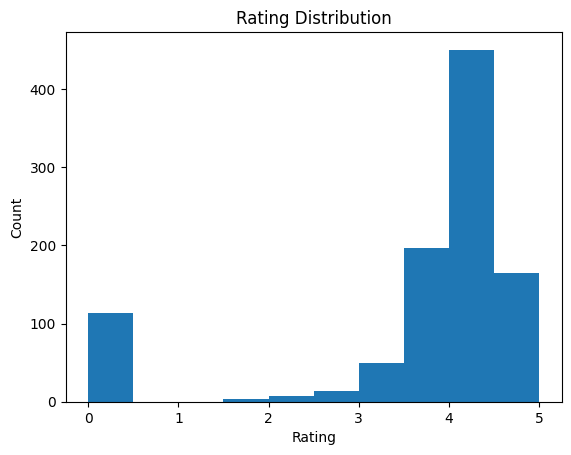


Top Categories:
category
tops            122
dresses         100
shirts           97
jeans            57
sports-shoes     51
Name: count, dtype: int64


In [8]:
print(df['rating'].describe()) # Univariate Analysis
print(df['category'].value_counts().head(10)) # Category Analysis

# Visualization
plt.hist(df['rating'], bins=10)
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()
print("\nTop Categories:")
print(df['category'].value_counts().head(5))

## Conclusion

The shopping dataset was successfully loaded and analyzed using Pandas. Missing values were identified and handled, duplicate records were removed, and basic operations such as filtering, selecting columns, and sorting were performed. A derived column (discount_value) was created to demonstrate feature engineering. Finally, the cleaned dataset was exported as a CSV file for future use.